# LSTM-GAT Trajectory End-to-End

Trajectory-based LSTM-GAT: concatenate all LSTM hidden states per stock,
compute attention once on the full trajectory vectors, predict one position per stock.

**Key difference from per-timestep GAT:** Loss is computed only on day 20's prediction
(the fully-informed one), not all 20 timesteps.

**Architecture**: Shared LSTM → Flatten 20×10=200 dims per stock → Full GAT → Position

## 1. Setup

In [20]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [21]:
import os
import sys

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annual_return, annual_volatility, calmar_ratio,
)

import random
random.seed(40)
np.random.seed(40)

import tensorflow as tf
tf.random.set_seed(40)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [23]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/features.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configuration

In [24]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023

VOL_TARGET = 0.15

# Stride Configuration
# Controls overlap between training windows:
#   TRAIN_STRIDE = 20 → non-overlapping (57 samples, matches paper)
#   TRAIN_STRIDE = 10 → 50% overlap (~140 samples)
#   TRAIN_STRIDE = 5  → 75% overlap (~280 samples)
#   TRAIN_STRIDE = 1  → full sliding (~1400 samples)
TRAIN_STRIDE = 1

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# GAT Hyperparameters
HIDDEN_LAYER_SIZE = 10
GAT_UNITS = 16
ATTN_HEADS = 4
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
MAX_GRADIENT_NORM = 1.0#0.01
NUM_GAT_LAYERS = 1
BATCH_SIZE = 128

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nModel: LSTM-GAT Trajectory End-to-End")
print(f"  Stride: {TRAIN_STRIDE}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print(f"  Dropout: {DROPOUT_RATE}, LR: {LEARNING_RATE}")

Train: 2011-2017
Test:  2017-2023

Model: LSTM-GAT Trajectory End-to-End
  Stride: 1
  GAT units: 16, heads: 4, layers: 1
  Dropout: 0.2, LR: 0.001


## 3. Helper Functions

In [25]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))

    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading

In [26]:
features_path = "/content/drive/MyDrive/features.csv"
#features_path = "data/straddle_features/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88


In [27]:
from gml.graph_model_inputs import GraphModelFeatures

features = GraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
    train_valid_sliding=True,  # Enable sliding windows for stride control
)

print("Feature generator created (sliding windows enabled).")

no lags


train _batch
After final stacking and culling:
inputs.shape: (1131, 88, 20, 10)
outputs.shape: (1131, 88, 20, 1)
active_entries.shape: (1131, 88, 20, 1)
identifier.shape: (1131, 88, 20, 1)
date.shape: (1131, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (269, 88, 20, 10)
outputs.shape: (269, 88, 20, 1)
active_entries.shape: (269, 88, 20, 1)
identifier.shape: (269, 88, 20, 1)
date.shape: (269, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Feature generator created (sliding windows enabled).


In [28]:
# Apply stride to training/validation data
# TRAIN_STRIDE=20 → non-overlapping (matches paper)
# TRAIN_STRIDE=1  → full sliding (maximum data)
train_data = {k: v[::TRAIN_STRIDE] for k, v in features.train.items()}
valid_data = {k: v[::TRAIN_STRIDE] for k, v in features.valid.items()}
test_data = features.test_sliding  # Test always uses stride=1

print(f"Stride: {TRAIN_STRIDE}")
print(f"\nTraining data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")
print(f"\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")

Stride: 1

Training data:
  inputs: (1131, 88, 20, 10)
  outputs: (1131, 88, 20, 1)

Validation data:
  inputs: (269, 88, 20, 10)

Test data:
  inputs: (1400, 88, 20, 10)


## 5. Model Definition

In [29]:
from gml.graph_model_gat_v2 import build_lstm_gat_trajectory_model

num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"Building LSTM-GAT Trajectory E2E model:")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps} (concat to {time_steps * HIDDEN_LAYER_SIZE} dims)")
print(f"  input_size: {input_size}")

model = build_lstm_gat_trajectory_model(
    num_tickers=num_tickers, time_steps=time_steps, input_size=input_size,
    hidden_layer_size=HIDDEN_LAYER_SIZE, gat_units=GAT_UNITS, attn_heads=ATTN_HEADS,
    dropout_rate=DROPOUT_RATE, learning_rate=LEARNING_RATE,
    max_gradient_norm=MAX_GRADIENT_NORM, num_gat_layers=NUM_GAT_LAYERS,
)

# model.summary()

Building LSTM-GAT Trajectory E2E model:
  num_tickers: 88
  time_steps: 20 (concat to 200 dims)
  input_size: 10


## 6. Training

In [30]:
# Extract last timestep labels only (trajectory predicts day 20 only)
X_train = train_data['inputs']
y_train = train_data['outputs'][:, :, -1:, :]  # (num_windows, 88, 1, 1)
y_train = y_train.squeeze(-1)  # (num_windows, 88, 1)
w_train = train_data['active_entries'][:, :, -1:, :].squeeze(-1)

X_valid = valid_data['inputs']
y_valid = valid_data['outputs'][:, :, -1:, :].squeeze(-1)
w_valid = valid_data['active_entries'][:, :, -1:, :].squeeze(-1)

print(f"Training: X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_valid.shape}, y={y_valid.shape}")

Training: X=(1131, 88, 20, 10), y=(1131, 88, 1)
Validation: X=(269, 88, 20, 10), y=(269, 88, 1)


In [31]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("="*60)
print("Training LSTM-GAT Trajectory E2E")
print(f"  Stride: {TRAIN_STRIDE} ({X_train.shape[0]} training samples)")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print("="*60)

history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GAT Trajectory E2E
  Stride: 1 (1131 training samples)
  GAT units: 16, heads: 4, layers: 1


Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - loss: -0.5925 - val_loss: -0.9900
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: -0.8213 - val_loss: -1.0257
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - loss: -0.9704 - val_loss: -0.8913
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: -1.1058 - val_loss: -0.9569
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: -1.1895 - val_loss: -0.9445
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: -1.2835 - val_loss: -0.8849
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: -1.3352 - val_loss: -0.6760
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: -1.4318 - val_loss: -0.8764
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: -1.5506 - val_loss: -0.6152
Epoch 10/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: -1.6629 - val_loss: -0.1038
Epoch 11/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - loss: -1.7056 - val_loss: -0.5619
Epoch 12/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15

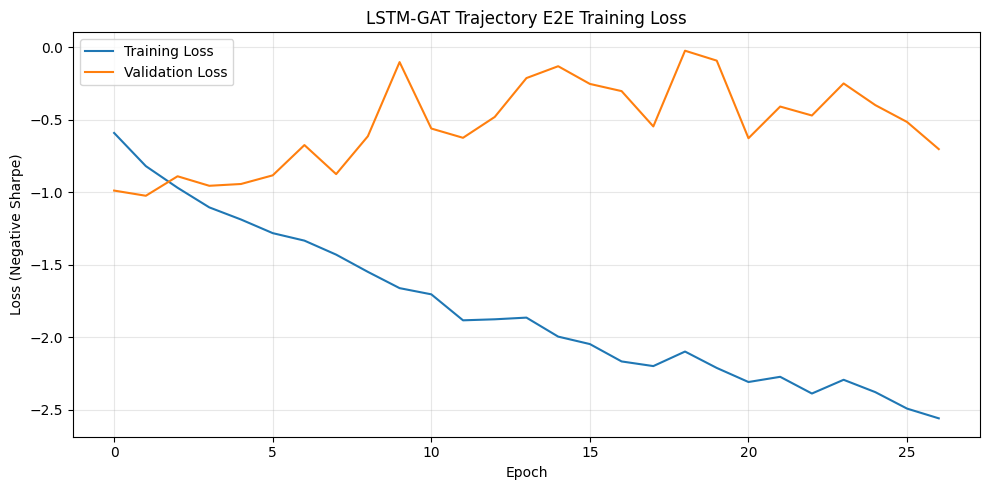

Epochs trained: 27
Best val loss: -1.0257


In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title('LSTM-GAT Trajectory E2E Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

## 7. Evaluation

In [33]:
X_test = test_data['inputs']
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step
Predictions shape: (1400, 88, 1)
Test outputs shape: (1400, 88, 20, 1)


In [34]:
# Trajectory model outputs (batch, 88, 1) — one prediction per stock per window
positions = predictions[:, :, 0].reshape(-1)
returns = test_data['outputs'][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

dates = test_data['date'][:, :, -1, 0].reshape(-1)
identifiers = test_data['identifier'][:, :, -1, 0].reshape(-1)

results_df = pd.DataFrame({
    'time': dates, 'identifier': identifiers,
    'position': positions, 'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,0.849683,-0.009874,-0.008390
1,2017-01-03,ABT,0.934201,-0.002442,-0.002282
2,2017-01-03,ACN,0.786996,-0.008236,-0.006482
3,2017-01-03,ADBE,0.478632,-0.010764,-0.005152
4,2017-01-03,AIG,0.717333,-0.003832,-0.002749


In [35]:
daily_returns = calc_daily_returns(results_df)

print("\n" + "="*60)
print("LSTM-GAT Traj E2E Results (Raw)")
print("="*60)

metrics_raw = calc_metrics(daily_returns, "LSTM-GAT Traj E2E")
display_metrics(metrics_raw)

print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, "LSTM-GAT Traj E2E", VOL_TARGET)
display_metrics(metrics_norm)

print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe_val in yearly_sharpes.items():
    print(f"  {year}: {sharpe_val:.4f}")


LSTM-GAT Traj E2E Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GAT Traj E2E,5.31%,4.89%,1.082,1.451,7.37%,0.720,58.21%,0.888



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GAT Traj E2E (Vol-Norm),16.29%,15.00%,1.082,1.451,21.50%,0.757,58.21%,0.888



Yearly Sharpe Ratios:
  2017: 3.2300
  2018: -0.8755
  2019: 1.9358
  2020: 0.6319
  2021: 1.8945
  2022: 0.5012


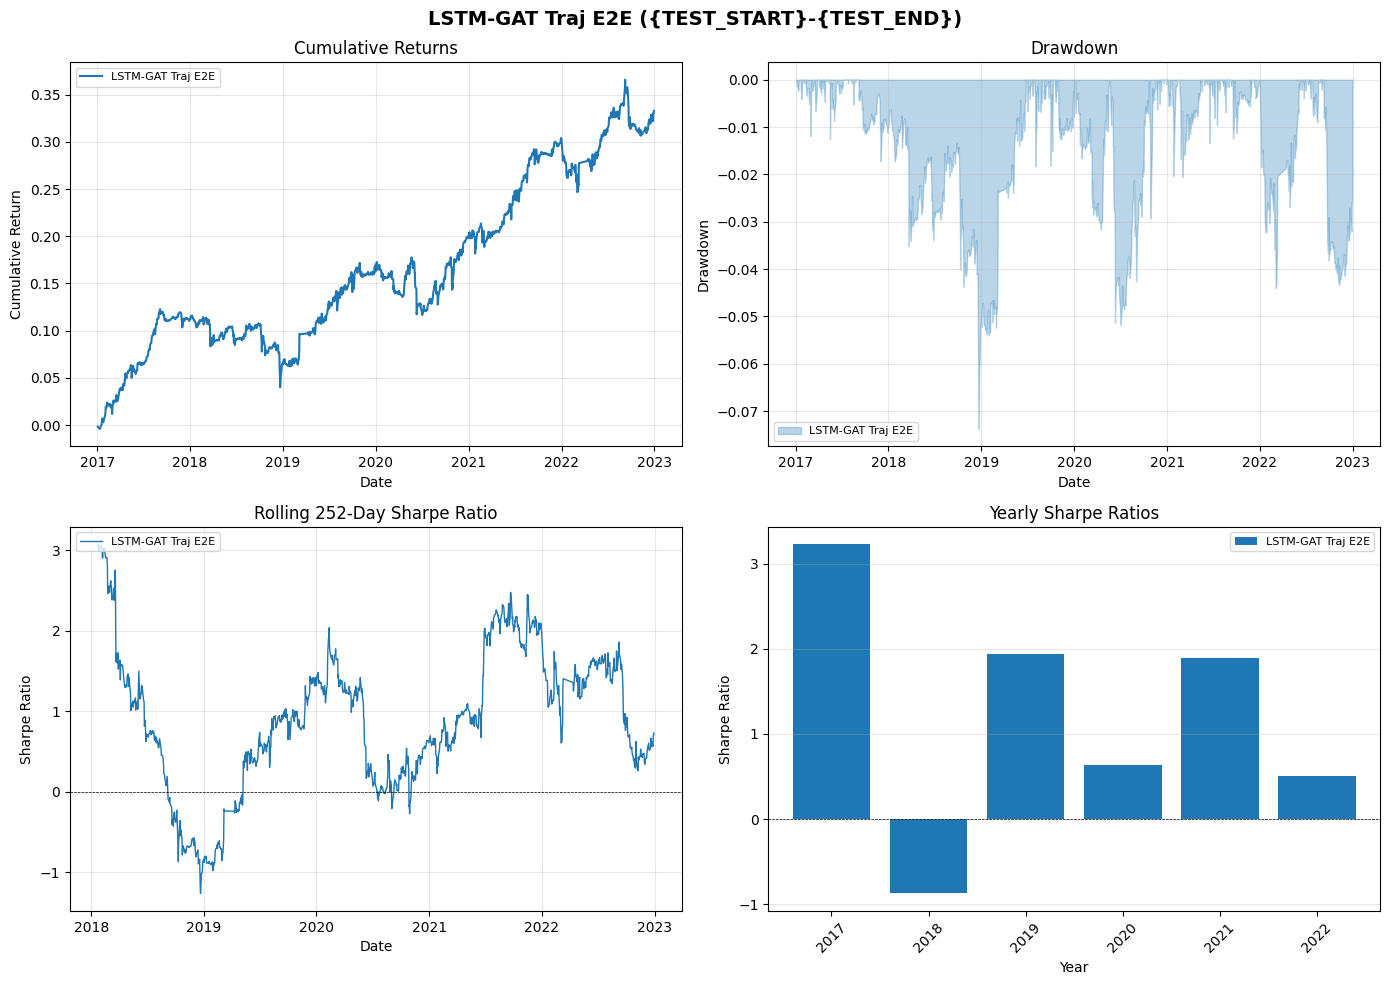

In [36]:
all_daily_returns = {'LSTM-GAT Traj E2E': daily_returns}
plot_results(all_daily_returns, "LSTM-GAT Traj E2E ({TEST_START}-{TEST_END})")

## 8. Position Analysis

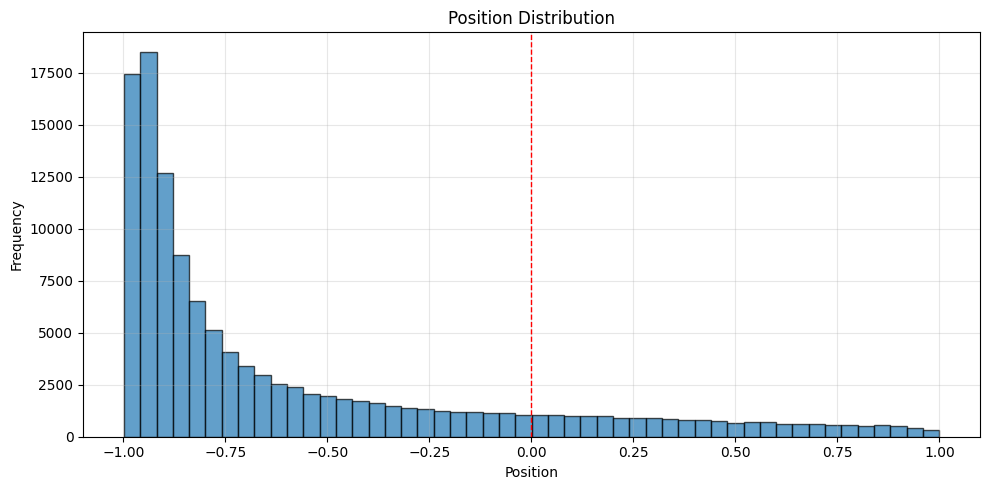

In [37]:
plt.figure(figsize=(10, 5))
plt.hist(results_df['position'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.title('Position Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Results

In [38]:
results_dir = f"results/lstm_gat_trajectory_e2e_s{TRAIN_STRIDE}_u{GAT_UNITS}_h{ATTN_HEADS}/{TEST_START}-{TEST_END}"
os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)
pd.DataFrame([metrics_raw]).to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)
pd.DataFrame([metrics_norm]).to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)
pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe']).to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gat_trajectory_e2e_s1_u16_h4/2017-2023
